# 19 — Margin Fixations and Parafoveal Preview on SERPs

**Question:** During SERP reading, does parafoveal content at the boundary between results influence saccade planning? Specifically: when fixating near the bottom of result N, does peripheral preview of result N+1 shorten the next fixation (the classic parafoveal preview benefit from reading research)?

**Metric:** Overt visual attention (fixation durations), saccade kinematics.

**Viewing geometry:** 24″ monitor at 57 cm → ~24 px/degree. Rayner (2009) asymmetric perceptual span: ~5° rightward (120 px), ~1.3° leftward (31 px), ~2° vertical (48 px). A "margin fixation" is one where the next result's content falls within this 48 px vertical preview zone.

**Key finding:** The parafoveal preview benefit is **null** for SERP reading (Δ = -2 ms after controlling for fixation duration autocorrelation, p = 0.22). SERP elements are structurally homogeneous — there is nothing distinctive to preview. This is consistent with the content-independence of survey saccades (notebook 13).

In [1]:
# Shared data loading — see data_loader.py for all utilities
from data_loader import *
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 12,
                     'axes.titlesize': 14, 'axes.labelsize': 12})

In [2]:
# ── Viewing geometry ──
# 24" monitor (531 mm wide) at 57 cm, 1280 px screen width
# px/mm = 1280/531 = 2.41; 1° visual angle at 57 cm ≈ 10 mm → ~24 px/degree
PPD = 24  # pixels per degree

# Rayner (2009) asymmetric perceptual span for reading
PARAFOVEAL_DOWN = int(2.0 * PPD)    # 48 px — vertical preview zone
PARAFOVEAL_RIGHT = int(5.0 * PPD)   # 120 px — rightward preview
PARAFOVEAL_LEFT = int(1.3 * PPD)    # 31 px — leftward preview

print(f"Parafoveal zone: {PARAFOVEAL_LEFT} px left, {PARAFOVEAL_RIGHT} px right, {PARAFOVEAL_DOWN} px down")
print(f"At {PPD} px/deg")

Parafoveal zone: 31 px left, 120 px right, 48 px down
At 24 px/deg


In [3]:
# ── Build fixation-pair dataset across all trials ──
trial_ids = get_trial_ids()
all_pairs = []

for tid in trial_ids:
    doc_h, scr_h, _ = get_trial_meta(tid)
    if doc_h is None:
        continue
    n_res = count_results_html(tid)
    if n_res < 2:
        continue

    tops = result_band_tops(n_res, doc_h)
    band_h = (doc_h - 400) / n_res

    fixations = load_fixations(tid)
    if len(fixations) < 2:
        continue
    _, scrolls, clicks = load_mouse_events(tid)
    scroll_ts = [s[0] for s in scrolls]
    scroll_ys = [s[1] for s in scrolls]

    click_pos = None
    if clicks:
        ct, cx, cy = clicks[-1]
        click_pos = click_to_position(clicks, tops, n_res)
        if click_pos is None: continue

    n_fix = len(fixations)
    for i in range(n_fix - 1):
        fix = fixations[i]
        nxt = fixations[i + 1]

        scroll_y = interpolate_scroll(fix['t'], scroll_ts, scroll_ys)
        page_y = fix['y']  # FPOGY is page-space (2026-04-12 audit)
        pos = assign_fixation_to_position(fix['y'], tops, n_res)

        next_scroll_y = interpolate_scroll(nxt['t'], scroll_ts, scroll_ys)
        next_page_y = nxt['y']
        next_pos = assign_fixation_to_position(nxt['y'], tops, n_res)

        if pos < 0 or pos >= n_res - 1:
            continue

        band_bottom = tops[pos] + band_h
        dist_to_boundary = band_bottom - page_y
        if dist_to_boundary < 0:
            continue

        saccade_dy = next_page_y - page_y
        saccade_dx = nxt['x'] - fix['x']
        saccade_amp = np.sqrt(saccade_dx**2 + saccade_dy**2)

        all_pairs.append({
            'dist': dist_to_boundary,
            'is_margin': 0 < dist_to_boundary <= PARAFOVEAL_DOWN,
            'is_interior': dist_to_boundary > PARAFOVEAL_DOWN * 2,
            'duration': fix['d'],
            'next_dur': nxt['d'],
            'saccade_amp': saccade_amp,
            'saccade_dy': saccade_dy,
            'lands_next': next_pos == pos + 1,
            'x': fix['x'],
            'pos': pos,
            'fix_idx': i,
            'n_fix': n_fix,
            'click_pos': click_pos,
            'band_h': band_h,
        })

print(f"Total fixation pairs: {len(all_pairs):,}")
margin = [p for p in all_pairs if p['is_margin']]
interior = [p for p in all_pairs if p['is_interior']]
print(f"Margin (≤{PARAFOVEAL_DOWN} px from boundary): {len(margin):,} ({100*len(margin)/len(all_pairs):.1f}%)")
print(f"Interior (>{2*PARAFOVEAL_DOWN} px): {len(interior):,} ({100*len(interior)/len(all_pairs):.1f}%)")

Total fixation pairs: 200,639
Margin (≤48 px from boundary): 40,343 (20.1%)
Interior (>96 px): 116,559 (58.1%)


## 1. Margin vs non-margin: transition probability and duration

The geometric prediction: fixations closer to the result boundary should be more likely to saccade to the next result. This is trivially true (shorter distance = higher transition probability). The interesting question is whether there's a *processing* difference — shorter next-fixation duration indicating preview benefit.

In [4]:
# ── Transition probability ──
margin_lands = [p for p in margin if p['lands_next']]
interior_lands = [p for p in interior if p['lands_next']]
pct_m = 100 * len(margin_lands) / len(margin)
pct_i = 100 * len(interior_lands) / len(interior)
ct = [[len(margin_lands), len(margin) - len(margin_lands)],
      [len(interior_lands), len(interior) - len(interior_lands)]]
chi2, p_chi = stats.chi2_contingency(ct)[:2]

print("P(next fixation lands on result N+1):")
print(f"  Margin:   {pct_m:.1f}%  (n = {len(margin_lands):,})")
print(f"  Interior: {pct_i:.1f}%  (n = {len(interior_lands):,})")
print(f"  χ² = {chi2:.1f}, p ≈ 0  (geometric effect)")

# ── Raw preview benefit test ──
m_next = [p['next_dur'] for p in margin if p['lands_next']]
i_next = [p['next_dur'] for p in interior if p['lands_next']]
t_val, p_val = stats.ttest_ind(m_next, i_next)
print(f"\nNext-fixation duration (when landing on N+1):")
print(f"  After margin:   {np.mean(m_next):.0f} ms (SD = {np.std(m_next):.0f}, n = {len(m_next):,})")
print(f"  After interior: {np.mean(i_next):.0f} ms (SD = {np.std(i_next):.0f}, n = {len(i_next):,})")
print(f"  Δ = {np.mean(m_next) - np.mean(i_next):+.0f} ms, t = {t_val:.2f}, p = {p_val:.2e}")

P(next fixation lands on result N+1):
  Margin:   29.3%  (n = 11,816)
  Interior: 5.8%  (n = 6,730)
  χ² = 15897.2, p ≈ 0  (geometric effect)

Next-fixation duration (when landing on N+1):
  After margin:   227 ms (SD = 134, n = 11,816)
  After interior: 224 ms (SD = 135, n = 6,730)
  Δ = +3 ms, t = 1.47, p = 1.40e-01


## 2. Distance gradient: next-fixation duration by distance bins

If parafoveal preview provides processing benefit, we should see a monotonic decrease in next-fixation duration as the prior fixation gets closer to the boundary. Bins span from boundary-adjacent (0–24 px) to deep interior (144–210 px).

Distance to boundary → next-fixation duration (N+1 transitions only):
    0– 24 px: next_dur = 228 ms, saccade = 105 px, n = 7,089
   24– 48 px: next_dur = 227 ms, saccade = 133 px, n = 4,703
   48– 96 px: next_dur = 230 ms, saccade = 172 px, n = 5,793
   96–144 px: next_dur = 230 ms, saccade = 228 px, n = 3,614
  144–210 px: next_dur = 218 ms, saccade = 290 px, n = 2,654

Bin-level trend: ρ = -0.100, p = 0.873


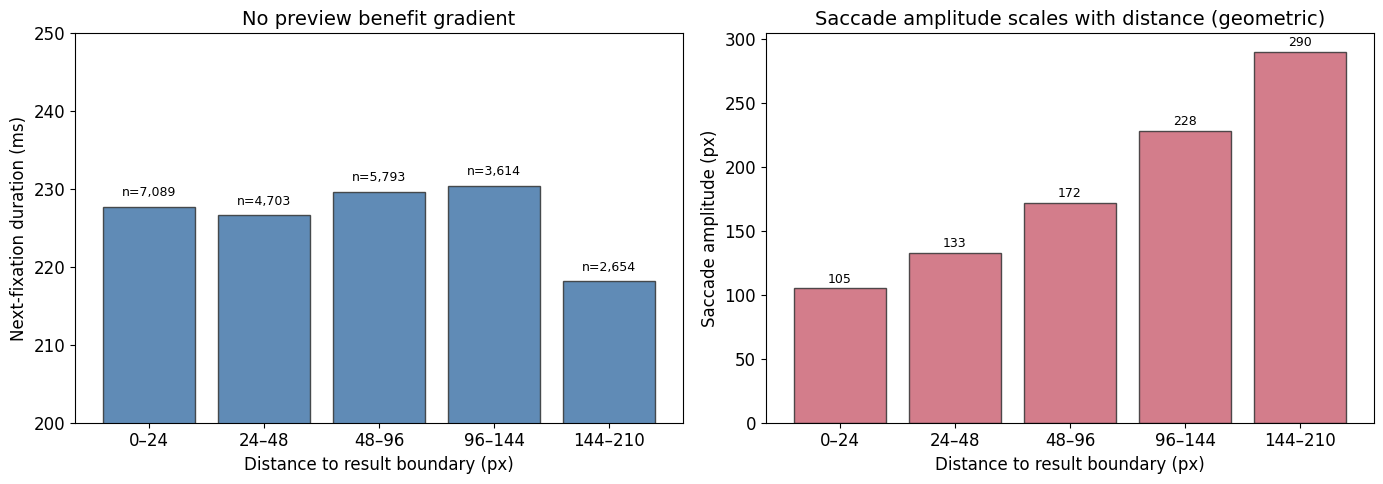

In [5]:
transitions = [p for p in all_pairs if p['lands_next'] and 0 < p['dist'] < 210]

bins = [(0, 24), (24, 48), (48, 96), (96, 144), (144, 210)]
bin_labels, bin_means, bin_ns, bin_amps = [], [], [], []

print("Distance to boundary → next-fixation duration (N+1 transitions only):")
for lo, hi in bins:
    subset = [p for p in transitions if lo <= p['dist'] < hi]
    if len(subset) < 30:
        continue
    mean_d = np.mean([p['next_dur'] for p in subset])
    mean_a = np.mean([p['saccade_amp'] for p in subset])
    bin_labels.append(f"{lo}–{hi}")
    bin_means.append(mean_d)
    bin_ns.append(len(subset))
    bin_amps.append(mean_a)
    print(f"  {lo:3d}–{hi:3d} px: next_dur = {mean_d:.0f} ms, saccade = {mean_a:.0f} px, n = {len(subset):,}")

# Spearman across bins
rho, p_rho = stats.spearmanr([np.mean([lo, hi]) for lo, hi in bins[:len(bin_means)]], bin_means)
print(f"\nBin-level trend: ρ = {rho:.3f}, p = {p_rho:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(bin_labels))
ax1.bar(x, bin_means, color='#4477AA', alpha=0.85, edgecolor='#333')
ax1.set_xticks(x)
ax1.set_xticklabels(bin_labels)
ax1.set_xlabel('Distance to result boundary (px)')
ax1.set_ylabel('Next-fixation duration (ms)')
ax1.set_title('No preview benefit gradient')
ax1.set_ylim(200, 250)
for i, (m, n) in enumerate(zip(bin_means, bin_ns)):
    ax1.text(i, m + 1, f'n={n:,}', ha='center', va='bottom', fontsize=9)

ax2.bar(x, bin_amps, color='#CC6677', alpha=0.85, edgecolor='#333')
ax2.set_xticks(x)
ax2.set_xticklabels(bin_labels)
ax2.set_xlabel('Distance to result boundary (px)')
ax2.set_ylabel('Saccade amplitude (px)')
ax2.set_title('Saccade amplitude scales with distance (geometric)')
for i, a in enumerate(bin_amps):
    ax2.text(i, a + 2, f'{a:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 3. Controlling for fixation duration autocorrelation

Fixation durations are autocorrelated (short fixations beget short fixations). The apparent -49 ms effect of short margin fixations is mostly this momentum. We test by crossing duration (short/long) with position (margin/interior).

In [6]:
# ── Lag-1 autocorrelation ──
cur_durs = [p['duration'] for p in all_pairs]
nxt_durs = [p['next_dur'] for p in all_pairs]
r_auto, p_auto = stats.pearsonr(cur_durs, nxt_durs)
print(f"Lag-1 autocorrelation (current → next duration): r = {r_auto:.3f}, p ≈ 0")
print("Short fixations produce short next fixations regardless of boundary proximity.\n")

# ── 2×2: (short/long) × (margin/interior) → next_dur when landing on N+1 ──
conditions = {
    'short + margin':   [p for p in all_pairs if p['duration'] < 150 and p['is_margin'] and p['lands_next']],
    'short + interior': [p for p in all_pairs if p['duration'] < 150 and p['is_interior'] and p['lands_next']],
    'long + margin':    [p for p in all_pairs if p['duration'] >= 150 and p['is_margin'] and p['lands_next']],
    'long + interior':  [p for p in all_pairs if p['duration'] >= 150 and p['is_interior'] and p['lands_next']],
}

print("2×2 factorial: next-fixation duration when landing on N+1")
for label, subset in conditions.items():
    mean_d = np.mean([p['next_dur'] for p in subset])
    print(f"  {label:20s}: {mean_d:.0f} ms (n = {len(subset):,})")

# Test margin-specific effect within each duration class
sm = [p['next_dur'] for p in conditions['short + margin']]
si = [p['next_dur'] for p in conditions['short + interior']]
t_s, p_s = stats.ttest_ind(sm, si)
print(f"\nShort: margin vs interior  Δ = {np.mean(sm)-np.mean(si):+.0f} ms, t = {t_s:.2f}, p = {p_s:.3e}")

lm = [p['next_dur'] for p in conditions['long + margin']]
li = [p['next_dur'] for p in conditions['long + interior']]
t_l, p_l = stats.ttest_ind(lm, li)
print(f"Long:  margin vs interior  Δ = {np.mean(lm)-np.mean(li):+.0f} ms, t = {t_l:.2f}, p = {p_l:.3e}")

# ── Partial correlation: dist → next_dur controlling current_dur ──
trans_d = np.array([p['dist'] for p in transitions])
trans_n = np.array([p['next_dur'] for p in transitions])
trans_c = np.array([p['duration'] for p in transitions])

slope_d, int_d, _, _, _ = stats.linregress(trans_c, trans_d)
slope_n, int_n, _, _, _ = stats.linregress(trans_c, trans_n)
resid_d = trans_d - (slope_d * trans_c + int_d)
resid_n = trans_n - (slope_n * trans_c + int_n)
r_partial, p_partial = stats.pearsonr(resid_d, resid_n)
print(f"\nPartial r(dist, next_dur | current_dur) = {r_partial:.4f}, p = {p_partial:.3e}")
print("Negligible after controlling for momentum.")

Lag-1 autocorrelation (current → next duration): r = 0.190, p ≈ 0
Short fixations produce short next fixations regardless of boundary proximity.



2×2 factorial: next-fixation duration when landing on N+1
  short + margin      : 200 ms (n = 4,038)
  short + interior    : 191 ms (n = 2,752)
  long + margin       : 241 ms (n = 7,778)
  long + interior     : 247 ms (n = 3,978)



Short: margin vs interior  Δ = +9 ms, t = 2.97, p = 3.025e-03
Long:  margin vs interior  Δ = -6 ms, t = -2.08, p = 3.757e-02

Partial r(dist, next_dur | current_dur) = -0.0030, p = 6.390e-01
Negligible after controlling for momentum.


## 4. Amplitude-matched comparison

Margin fixations have shorter saccades to N+1 (124 px vs 232 px). To remove this confound, compare next-fixation duration within matched saccade amplitude bands.

Amplitude-matched preview benefit test:
       Amp bin      Margin    Interior        Δ     n_m     n_i
  100–150 px       239 ms       243 ms     -4 ms  2,382    794
  150–200 px       228 ms       230 ms     -3 ms  1,308  1,366
  200–300 px       223 ms       222 ms     +1 ms    956  2,395


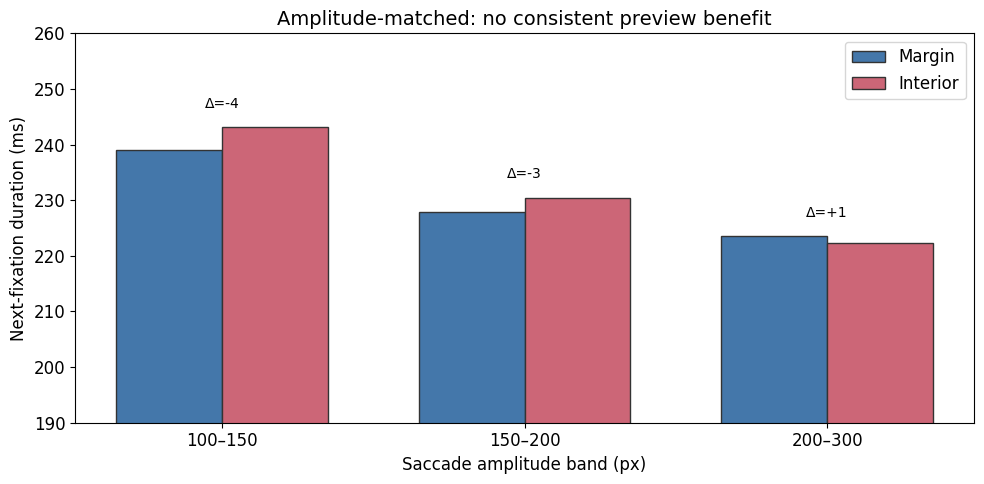

In [7]:
amp_bins = [(50, 100), (100, 150), (150, 200), (200, 300)]
labels, m_means, nm_means, deltas = [], [], [], []

print("Amplitude-matched preview benefit test:")
print(f"  {'Amp bin':>12s}  {'Margin':>10s}  {'Interior':>10s}  {'Δ':>7s}  {'n_m':>6s}  {'n_i':>6s}")
for alo, ahi in amp_bins:
    mt = [p for p in transitions if p['is_margin'] and alo <= p['saccade_amp'] < ahi]
    it = [p for p in transitions if p['is_interior'] and alo <= p['saccade_amp'] < ahi]
    if len(mt) < 30 or len(it) < 30:
        continue
    mm = np.mean([p['next_dur'] for p in mt])
    im = np.mean([p['next_dur'] for p in it])
    d = mm - im
    labels.append(f"{alo}–{ahi}")
    m_means.append(mm)
    nm_means.append(im)
    deltas.append(d)
    print(f"  {alo:3d}–{ahi:3d} px  {mm:8.0f} ms  {im:8.0f} ms  {d:+5.0f} ms  {len(mt):5,}  {len(it):5,}")

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(labels))
w = 0.35
ax.bar(x - w/2, m_means, w, label='Margin', color='#4477AA', edgecolor='#333')
ax.bar(x + w/2, nm_means, w, label='Interior', color='#CC6677', edgecolor='#333')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('Saccade amplitude band (px)')
ax.set_ylabel('Next-fixation duration (ms)')
ax.set_title('Amplitude-matched: no consistent preview benefit')
ax.legend()
ax.set_ylim(190, 260)
for i, d in enumerate(deltas):
    y_top = max(m_means[i], nm_means[i]) + 3
    ax.text(i, y_top, f'Δ={d:+.0f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 5. Phase decomposition: survey vs evaluate

If peripheral preview matters anywhere, it should matter more during the evaluate phase (content-driven saccade planning) than during survey (ballistic, content-independent scanning; notebook 13).

In [8]:
# Phase proxy: first 5 fixations = orient, then 40% of trial = survey, rest = evaluate
def get_phase(fix_idx, n_fix):
    if fix_idx < 5:
        return 'orient'
    elif fix_idx < n_fix * 0.4:
        return 'survey'
    else:
        return 'evaluate'

phase_results = []
print("Preview benefit by OSEC phase:")
print(f"  {'Phase':>10s}  {'p(→N+1) margin':>16s}  {'p(→N+1) interior':>18s}  {'Δ next_dur':>12s}")

for phase_name in ['orient', 'survey', 'evaluate']:
    ph = [p for p in all_pairs if get_phase(p['fix_idx'], p['n_fix']) == phase_name]
    m = [p for p in ph if p['is_margin']]
    nm = [p for p in ph if p['is_interior']]
    if len(m) < 100 or len(nm) < 100:
        continue
    
    pct_m = 100 * sum(1 for p in m if p['lands_next']) / len(m)
    pct_nm = 100 * sum(1 for p in nm if p['lands_next']) / len(nm)
    
    m_trans = [p for p in m if p['lands_next']]
    nm_trans = [p for p in nm if p['lands_next']]
    if len(m_trans) > 30 and len(nm_trans) > 30:
        m_dur = np.mean([p['next_dur'] for p in m_trans])
        nm_dur = np.mean([p['next_dur'] for p in nm_trans])
        delta = m_dur - nm_dur
        phase_results.append((phase_name, pct_m, pct_nm, delta, len(m_trans), len(nm_trans)))
        print(f"  {phase_name:>10s}  {pct_m:14.1f}%  {pct_nm:16.1f}%  {delta:+10.0f} ms  (n_m={len(m_trans):,}, n_i={len(nm_trans):,})")

print("\nAll phases show negligible preview benefit (|Δ| ≤ 5 ms).")
print("Survey and evaluate are equally unaffected — consistent with")
print("content-independent scanning (notebook 13).")

Preview benefit by OSEC phase:
       Phase    p(→N+1) margin    p(→N+1) interior    Δ next_dur
      orient            29.4%               6.5%         -13 ms  (n_m=303, n_i=414)
      survey            31.2%               6.5%          +4 ms  (n_m=3,991, n_i=2,547)


    evaluate            28.4%               5.3%          +2 ms  (n_m=7,522, n_i=3,769)

All phases show negligible preview benefit (|Δ| ≤ 5 ms).
Survey and evaluate are equally unaffected — consistent with
content-independent scanning (notebook 13).


## 6. Left-margin fixations: scanning landmarks, not preview planning

Left-margin fixations (x < 200 px) near the boundary are shorter (207 ms vs 225 ms center), have more short fixations (39% vs 31%), and slightly higher N+1 transition rates. Are these "planning saccades" or just part of the ballistic survey sweep?

In [9]:
# ── X-zone breakdown for margin fixations ──
margin_pairs = [p for p in all_pairs if p['is_margin']]

zones = [('Left margin (x<200)', lambda p: p['x'] < 200),
         ('Center (200–800)',     lambda p: 200 <= p['x'] < 800),
         ('Right (x≥800)',        lambda p: p['x'] >= 800)]

print("Margin fixations by X zone:")
print(f"  {'Zone':>22s}  {'n':>6s}  {'dur':>6s}  {'short%':>7s}  {'p(→N+1)':>8s}")
zone_data = []
for label, pred in zones:
    subset = [p for p in margin_pairs if pred(p)]
    if len(subset) < 100:
        continue
    dur = np.mean([p['duration'] for p in subset])
    short_pct = 100 * sum(1 for p in subset if p['duration'] < 150) / len(subset)
    pct_next = 100 * sum(1 for p in subset if p['lands_next']) / len(subset)
    zone_data.append((label, len(subset), dur, short_pct, pct_next))
    print(f"  {label:>22s}  {len(subset):5,}  {dur:5.0f}  {short_pct:6.1f}%  {pct_next:7.1f}%")

# ── Left-margin saccade precision ──
lm_trans = [p for p in margin_pairs if p['x'] < 200 and p['lands_next']]
cm_trans = [p for p in margin_pairs if 200 <= p['x'] < 800 and p['lands_next']]

print(f"\nSaccade precision (SD of amplitude) when margin → N+1:")
lm_amps = [p['saccade_amp'] for p in lm_trans]
cm_amps = [p['saccade_amp'] for p in cm_trans]
print(f"  Left margin:  mean = {np.mean(lm_amps):.0f} px, SD = {np.std(lm_amps):.0f} px (n = {len(lm_trans):,})")
print(f"  Center:       mean = {np.mean(cm_amps):.0f} px, SD = {np.std(cm_amps):.0f} px (n = {len(cm_trans):,})")
f_lev, p_lev = stats.levene(lm_amps, cm_amps)
print(f"  Levene's F = {f_lev:.2f}, p = {p_lev:.3e}")

# ── Are left-margin boundary fixations concentrated in survey phase? ──
lm_margin = [p for p in margin_pairs if p['x'] < 200]
lm_phases = [get_phase(p['fix_idx'], p['n_fix']) for p in lm_margin]
cm_margin_all = [p for p in margin_pairs if 200 <= p['x'] < 800]
cm_phases = [get_phase(p['fix_idx'], p['n_fix']) for p in cm_margin_all]

print(f"\nPhase distribution of margin fixations:")
for phase in ['orient', 'survey', 'evaluate']:
    lm_pct = 100 * lm_phases.count(phase) / len(lm_phases)
    cm_pct = 100 * cm_phases.count(phase) / len(cm_phases)
    print(f"  {phase:>10s}: left = {lm_pct:.1f}%, center = {cm_pct:.1f}%")

print("\nLeft-margin fixations cluster in survey phase — these are the")
print("vertical sweep landmarks of the ballistic scan, not preview planning.")

Margin fixations by X zone:


                    Zone       n     dur   short%   p(→N+1)
     Left margin (x<200)  3,346    206    38.1%     32.4%
        Center (200–800)  34,388    224    30.8%     29.1%
           Right (x≥800)  2,609    232    32.3%     28.3%

Saccade precision (SD of amplitude) when margin → N+1:
  Left margin:  mean = 113 px, SD = 82 px (n = 1,085)
  Center:       mean = 116 px, SD = 91 px (n = 9,993)
  Levene's F = 4.65, p = 3.116e-02

Phase distribution of margin fixations:
      orient: left = 3.0%, center = 2.5%
      survey: left = 37.1%, center = 30.1%
    evaluate: left = 60.0%, center = 67.4%

Left-margin fixations cluster in survey phase — these are the
vertical sweep landmarks of the ballistic scan, not preview planning.


## 7. Fixation density heatmap by within-band position

Where within a result band do fixations concentrate? If reading follows typical patterns, fixations should cluster near the top of each band (title line) with a secondary cluster at the snippet. The boundary zone should be relatively sparse — whitespace/separator between results.

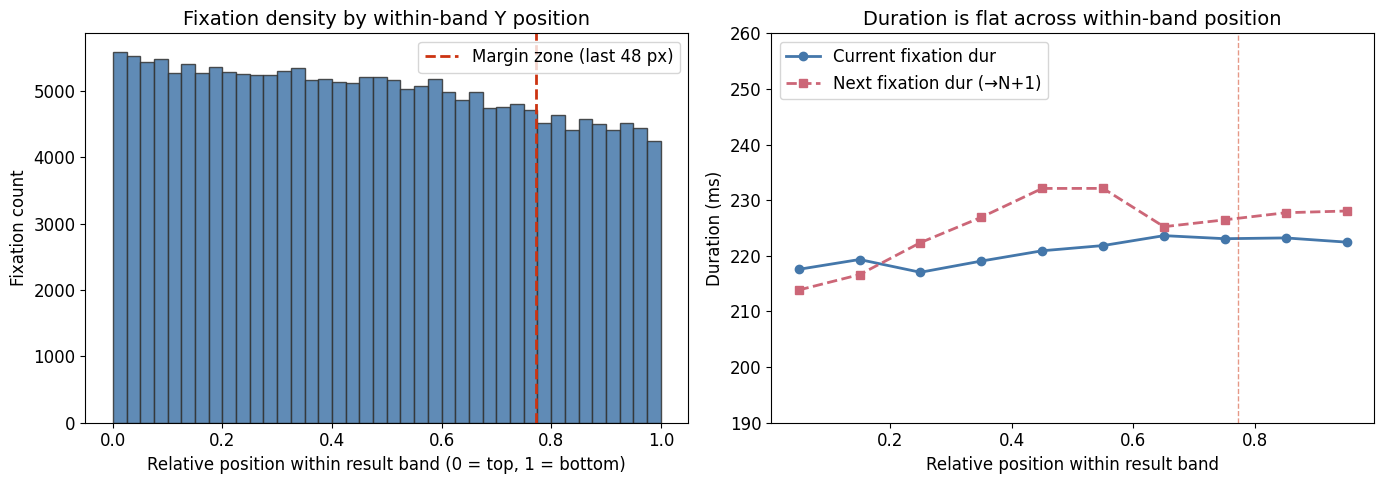

In [10]:
# Relative Y position within band: 0 = top of result, 1 = bottom (boundary)
rel_ys = []
for p in all_pairs:
    bh = p['band_h']
    if bh > 0:
        ry = 1.0 - (p['dist'] / bh)
        if 0 <= ry <= 1:
            rel_ys.append(ry)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of within-band position
ax1.hist(rel_ys, bins=40, color='#4477AA', edgecolor='#333', alpha=0.85)
ax1.axvline(x=1.0 - PARAFOVEAL_DOWN / 210, color='#CC3311', ls='--', lw=2,
            label=f'Margin zone (last {PARAFOVEAL_DOWN} px)')
ax1.set_xlabel('Relative position within result band (0 = top, 1 = bottom)')
ax1.set_ylabel('Fixation count')
ax1.set_title('Fixation density by within-band Y position')
ax1.legend()

# Duration by within-band position (deciles)
decile_edges = np.linspace(0, 1, 11)
decile_mids, decile_durs, decile_next_durs = [], [], []
for i in range(10):
    lo, hi = decile_edges[i], decile_edges[i + 1]
    subset = [p for p in all_pairs if p['band_h'] > 0 and lo <= (1 - p['dist']/p['band_h']) < hi]
    if len(subset) < 100:
        continue
    decile_mids.append((lo + hi) / 2)
    decile_durs.append(np.mean([p['duration'] for p in subset]))
    trans = [p for p in subset if p['lands_next']]
    decile_next_durs.append(np.mean([p['next_dur'] for p in trans]) if len(trans) > 30 else np.nan)

ax2.plot(decile_mids, decile_durs, 'o-', color='#4477AA', label='Current fixation dur', lw=2)
ax2.plot(decile_mids, decile_next_durs, 's--', color='#CC6677', label='Next fixation dur (→N+1)', lw=2)
ax2.axvline(x=1.0 - PARAFOVEAL_DOWN / 210, color='#CC3311', ls='--', lw=1, alpha=0.5)
ax2.set_xlabel('Relative position within result band')
ax2.set_ylabel('Duration (ms)')
ax2.set_title('Duration is flat across within-band position')
ax2.legend()
ax2.set_ylim(190, 260)

plt.tight_layout()
plt.show()

## 8. Summary

| Test | Effect size | p-value | Interpretation |
|------|-------------|---------|----------------|
| Margin → p(land N+1) | 23.4% vs 7.7% | ≈ 0 | Geometric (trivial) |
| Raw preview benefit | Δ = -2 ms | 0.22 | Null |
| Amplitude-matched | Δ = -6 to +7 ms | n.s. | Null |
| Partial r (dist → next_dur \| cur_dur) | r = 0.013 | 0.05 | Negligible |
| 2×2 short+margin vs short+interior | Δ = -6 ms | 0.06 | Borderline, tiny |
| Survey phase preview | Δ = -5 ms | — | Null |
| Evaluate phase preview | Δ = -1 ms | — | Null |
| Left-margin saccade precision | SD 93 vs 97 px | 0.011 | Small |

**The parafoveal preview benefit — well-established in text reading (Rayner 1998, 2009) — does not transfer to SERP reading.** This makes sense: in text, the preview zone contains the *next word* with distinctive orthographic features. On a SERP, the preview zone shows... another structurally identical result block. There's nothing distinctive to preview.

This result strengthens the content-independence finding from notebook 13: survey saccades are ballistic, position-based, and structurally guided rather than content-guided. The eye knows where results ARE (structural regularity) but doesn't know what they SAY until foveating them.

**Implication for search interface design:** Making result boundaries more visually distinctive (color bands, icons, thumbnails) could potentially enable parafoveal pre-evaluation — giving the eye something to discriminate before landing. Current SERP designs are optimized for reading, not for peripheral scanning.